In [32]:
from pathlib import Path

print("CWD:", Path.cwd())

for p in Path(".").rglob("test.csv"):
    print("TEST:", p)

for p in Path(".").rglob("label_to_supercategory_v1.csv"):
    print("MAP:", p)

CWD: /Users/natashaagapova/Documents/A-INNOPOLIS/A-THESIS/my-repository/notebooks


In [33]:
import os
import re
import json
import gc
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import joblib
from pathlib import Path
from collections import defaultdict
from tqdm.auto import tqdm
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, f1_score

# Paths — edit if needed
BASE_DIR = Path(".")
MODELS_BASE = Path("models")
TEST_CSV = Path("../data/processed/test.csv")
OUTPUT_DIR = Path("results/city_swap_all")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [34]:
# (name, subfolder, uses_scrubbing)
MODELS = [
    ("1_baseline",               "bert_9classes_final",          False),
    ("2_groupdro",               "bert_gdro_eta01_2ep",          False),
    ("3_scrubbing",              "bert_scrubbing",               True),
    ("4_oversampling",           "bert_oversample_only",         False),
    ("5_focal_loss",             "bert_focal_loss",              False),
    ("6_adversarial",            "bert_adversarial",             False),
    ("7_label_smoothing",        "bert_label_smoothing",         False),
    ("8_attribution_reg",        "bert_attr_reg",                False),
    ("9_combined_scrub_gdro",    "bert_debiased_combo",          True),
    ("10_combined_best",         "combined_scrubbing_groupdro",  True),
]

SWAP_CITIES = ["Москва", "Екатеринбург", "Новосибирск", "Краснодар", "Воронеж"]
BATCH_SIZE = 8
MAX_LENGTH = 128

In [35]:
CITY_PATTERNS = [
    "санкт-петербург", "нижний новгород", "ростов-на-дону",
    "набережные челны", "магнитогорск", "новосибирск",
    "екатеринбург", "красноярск", "волгоград", "калининград",
    "владивосток", "хабаровск", "ставрополь", "саратов",
    "челябинск", "самара", "казань", "москва", "омск",
    "воронеж", "пермь", "тюмень", "томск", "уфа",
    "тольятти", "барнаул", "иркутск", "пенза", "липецк",
    "кемерово", "сочи", "тверь", "минск", "алматы",
    "симферополь", "ярославль", "ульяновск", "ижевск",
    "оренбург", "мск", "спб", "питер",
]
escaped = [re.escape(c) for c in CITY_PATTERNS]
CITY_RE = re.compile(r'\b(' + '|'.join(escaped) + r')\b', re.IGNORECASE)

CITY_WORDS_SCRUB = [
    "москва", "московская", "московский", "мск",
    "санкт-петербург", "петербург", "спб", "питер", "ленинград",
    "новосибирск", "екатеринбург", "казань", "нижний новгород",
    "челябинск", "самара", "омск", "ростов-на-дону", "уфа",
    "красноярск", "воронеж", "пермь", "волгоград",
    "краснодар", "саратов", "тюмень", "тольятти", "ижевск",
    "барнаул", "ульяновск", "иркутск", "хабаровск", "ярославль",
    "владивосток", "махачкала", "томск", "оренбург", "кемерово",
    "новокузнецк", "рязань", "астрахань", "пенза", "липецк",
    "калининград", "тула", "курск", "ставрополь", "сочи",
    "магнитогорск", "томская", "набережные челны", "тверь",
    "минск", "алматы", "киев", "симферополь",
    "область", "край", "республика", "регион",
]
AGE_WORDS = [
    "пенсионер", "пенсионерка", "пенсия", "пенсионный",
    "студент", "студентка", "выпускник", "выпускница",
    "молодой", "молодая", "junior", "senior",
]
ALL_SENSITIVE = set(w.lower() for w in CITY_WORDS_SCRUB + AGE_WORDS)


def swap_cities_in_text(text, target_city):
    if pd.isna(text):
        return ""
    def replacer(match):
        orig = match.group(0)
        return target_city.capitalize() if orig[0].isupper() else target_city.lower()
    return CITY_RE.sub(replacer, str(text))


def scrub_text(text, mask_token="[MASK]"):
    if pd.isna(text):
        return ""
    result = str(text)
    for word in sorted(ALL_SENSITIVE, key=len, reverse=True):
        result = re.compile(re.escape(word), re.IGNORECASE).sub(mask_token, result)
    return result


def predict_batch(texts, model, tokenizer, device, batch_size=BATCH_SIZE):
    all_preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i + batch_size]
        enc = tokenizer(batch, padding=True, truncation=True,
                        max_length=MAX_LENGTH, return_tensors="pt")
        enc = {k: v.to(device) for k, v in enc.items()}
        with torch.no_grad():
            outputs = model(**enc)
            preds = outputs.logits.argmax(dim=-1)
        all_preds.extend(preds.cpu().numpy())
        del enc, outputs
    return np.array(all_preds)

In [36]:
df = pd.read_csv(TEST_CSV)
print(f"Test resumes: {len(df)}")

Test resumes: 5510


In [37]:
def find_model_files(model_dir):
    model_dir = Path(model_dir)
    if (model_dir / "config.json").exists():
        return "hf", model_dir
    if (model_dir / "bert" / "config.json").exists() and (model_dir / "classifier.pt").exists():
        return "split_classifier", model_dir
    candidates = [sub for sub in model_dir.iterdir()
                  if sub.is_dir() and (sub / "config.json").exists()]
    if candidates:
        for c in candidates:
            if c.name == "final":
                return "hf", c
        return "hf", sorted(candidates)[-1]
    return None, None


def _extract_state_dict(obj):
    if isinstance(obj, nn.Module):
        return obj.state_dict()
    if isinstance(obj, dict):
        for key in ["state_dict", "model_state_dict", "classifier_state_dict"]:
            if key in obj and isinstance(obj[key], dict):
                return obj[key]
        return obj
    return None


def _load_split_classifier_weights(model, model_dir):
    model_dir = Path(model_dir)
    classifier_paths = [model_dir / "classifier.pt", model_dir / "model.pt"]
    target_state = model.classifier.state_dict()

    for candidate in classifier_paths:
        if not candidate.exists():
            continue
        obj = torch.load(candidate, map_location="cpu")
        state = _extract_state_dict(obj)
        if not isinstance(state, dict):
            continue

        remapped = {}
        for key, value in state.items():
            norm_key = key.replace("module.", "")
            if norm_key.startswith("classifier."):
                norm_key = norm_key[len("classifier."):]
            if norm_key in target_state and getattr(value, "shape", None) == target_state[norm_key].shape:
                remapped[norm_key] = value

        if set(remapped.keys()) == set(target_state.keys()):
            model.classifier.load_state_dict(remapped, strict=True)
            return True

    return False


def load_model_safe(model_name, model_dir, device):
    fmt, path = find_model_files(model_dir)
    if fmt is None:
        print(f"  No model files found in {model_dir}")
        return None
    try:
        if fmt == "split_classifier":
            bert_path = path / "bert"
            tokenizer_path = path if (path / "tokenizer.json").exists() else bert_path
            tokenizer = AutoTokenizer.from_pretrained(str(tokenizer_path))
            model, loading_info = AutoModelForSequenceClassification.from_pretrained(
                str(bert_path),
                output_loading_info=True,
            )
            missing_keys = set(loading_info.get("missing_keys", []))
            missing_classifier = any(k.startswith("classifier.") for k in missing_keys)
            if missing_classifier and not _load_split_classifier_weights(model, path):
                print(f"  Invalid split checkpoint for evaluation: could not restore classifier head from {path}")
                return None
        else:
            tokenizer = AutoTokenizer.from_pretrained(str(path))
            model, loading_info = AutoModelForSequenceClassification.from_pretrained(
                str(path),
                output_loading_info=True,
            )
            missing_keys = set(loading_info.get("missing_keys", []))
            missing_classifier = any(k.startswith("classifier.") for k in missing_keys)
            if missing_classifier:
                print(f"  Invalid checkpoint for evaluation: missing classifier head {sorted(missing_keys)}")
                return None
        model = model.to(device).eval()
        le = None
        for le_path in [path / "label_encoder.joblib",
                        path.parent / "label_encoder.joblib",
                        model_dir / "label_encoder.joblib"]:
            if le_path.exists():
                le = joblib.load(le_path)
                break
        if le is None:
            print(f"  No label_encoder.joblib found for {model_name}")
            return None
        return {"model": model, "tokenizer": tokenizer, "le": le}
    except Exception as e:
        print(f"  Failed to load: {e}")
        return None

In [38]:
# Ensure df is defined and has the required columns before applying scrub_text
if 'df' not in locals():
    # Attempt to load the dataframe if not defined
    import pandas as pd
    from pathlib import Path
    df_path = Path("../data/processed/resume_data.csv")
    if df_path.exists():
        df = pd.read_csv(df_path)
    else:
        raise NameError("DataFrame 'df' is not defined and source file is missing.")

if "resume_text" not in df.columns:
    raise KeyError("'resume_text' column not found in the dataframe.")

df["text_scrubbed"] = df["resume_text"].apply(scrub_text)
print("Scrubbing done")

Scrubbing done


In [39]:
mapping = pd.read_csv(Path("../data/processed/label_to_supercategory_v1.csv"))
l2s = dict(zip(mapping["label"], mapping["supercategory"]))

In [40]:
all_results = {}

for model_name, model_subdir, uses_scrub in MODELS:
    model_dir = MODELS_BASE / model_subdir
    print(f"\n{'='*60}")
    print(f"{model_name} ({model_subdir})")

    if not model_dir.exists():
        print("  Directory not found, skipping")
        all_results[model_name] = {"error": "directory not found"}
        continue

    loaded = load_model_safe(model_name, model_dir, device)
    if loaded is None:
        all_results[model_name] = {"error": "failed to load"}
        continue

    model = loaded["model"]
    tokenizer = loaded["tokenizer"]
    le = loaded["le"]
    class_names = le.classes_

    if uses_scrub:
        base_texts = df["text_scrubbed"].tolist()
    else:
        base_texts = df["resume_text"].fillna("").astype(str).tolist()
    orig_preds = predict_batch(base_texts, model, tokenizer, device)

    if uses_scrub:
        print("  Scrubbing model — evaluating swaps after masking sensitive tokens")

    city_results = {}
    any_flip = np.zeros(len(df), dtype=bool)

    for swap_city in SWAP_CITIES:
        swapped_series = df["resume_text"].apply(
            lambda x: swap_cities_in_text(x, swap_city)
        )
        if uses_scrub:
            swapped = swapped_series.apply(scrub_text).tolist()
        else:
            swapped = swapped_series.fillna("").astype(str).tolist()

        swap_preds = predict_batch(swapped, model, tokenizer, device)
        flipped = (swap_preds != orig_preds)
        flip_rate = float(flipped.mean())
        any_flip |= flipped

        city_results[swap_city] = {
            "flip_rate": flip_rate,
            "num_flipped": int(flipped.sum()),
            "num_total": len(df),
        }
        print(f"  {swap_city}: {flip_rate:.3f} ({flipped.sum()}/{len(df)})")

        del swap_preds, flipped, swapped, swapped_series
        gc.collect()

    overall_flip = float(any_flip.mean())
    per_class = {}
    for i, cn in enumerate(class_names):
        mask = orig_preds == i
        if mask.sum() > 0:
            per_class[cn] = float(any_flip[mask].mean())

    y_true = le.transform(df["label"].map(l2s).fillna("generic_it_ops"))
    acc = float(accuracy_score(y_true, orig_preds))
    f1 = float(f1_score(y_true, orig_preds, average="macro"))

    all_results[model_name] = {
        "model_dir": model_subdir,
        "uses_scrubbing": uses_scrub,
        "accuracy": acc,
        "macro_f1": f1,
        "overall_flip_rate": overall_flip,
        "per_city_flip_rate": city_results,
        "per_class_flip_rate": per_class,
    }
    print(f"  Acc={acc:.3f}  F1={f1:.3f}  Flip={overall_flip:.3f}")

    del model, tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


1_baseline (bert_9classes_final)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1582.64it/s, Materializing param=classifier.weight]                                      


  Москва: 0.020 (110/5510)
  Екатеринбург: 0.042 (230/5510)
  Новосибирск: 0.043 (237/5510)
  Краснодар: 0.046 (252/5510)
  Воронеж: 0.032 (175/5510)
  Acc=0.609  F1=0.621  Flip=0.077

2_groupdro (bert_gdro_eta01_2ep)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1438.14it/s, Materializing param=classifier.weight]                                      


  Москва: 0.026 (145/5510)
  Екатеринбург: 0.048 (263/5510)
  Новосибирск: 0.073 (402/5510)
  Краснодар: 0.040 (219/5510)
  Воронеж: 0.046 (256/5510)
  Acc=0.548  F1=0.553  Flip=0.116

3_scrubbing (bert_scrubbing)


...

  Invalid split checkpoint for evaluation: could not restore classifier head from models/bert_attr_reg

9_combined_scrub_gdro (bert_debiased_combo)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2430.29it/s, Materializing param=classifier.weight]                                      


  Scrubbing model — evaluating swaps after masking sensitive tokens
  Москва: 0.000 (0/5510)
  Екатеринбург: 0.000 (0/5510)
  Новосибирск: 0.000 (0/5510)
  Краснодар: 0.000 (0/5510)
  Воронеж: 0.000 (0/5510)
  Acc=0.487  F1=0.475  Flip=0.000

10_combined_best (combined_scrubbing_groupdro)


Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2615.05it/s, Materializing param=classifier.weight]                                      


  Scrubbing model — evaluating swaps after masking sensitive tokens
  Москва: 0.000 (0/5510)
  Екатеринбург: 0.000 (0/5510)
  Новосибирск: 0.000 (0/5510)
  Краснодар: 0.000 (0/5510)
  Воронеж: 0.000 (0/5510)
  Acc=0.576  F1=0.597  Flip=0.000


In [41]:
print(f"{'Model':<30} {'Acc':>7} {'F1':>7} {'Flip%':>8} {'Scrub':>6}")
print("-" * 58)
for name, res in all_results.items():
    if "error" in res:
        print(f"{name:<30} {'ERROR':>21}")
    else:
        scr = "Y" if res["uses_scrubbing"] else ""
        print(f"{name:<30} {res['accuracy']:>7.3f} {res['macro_f1']:>7.3f} {res['overall_flip_rate']:>8.3f} {scr:>6}")

Model                              Acc      F1    Flip%  Scrub
----------------------------------------------------------
1_baseline                       0.609   0.621    0.077       
2_groupdro                       0.548   0.553    0.116       
3_scrubbing                      0.594   0.611    0.000      Y
4_oversampling                   0.601   0.611    0.100       
5_focal_loss                     0.593   0.613    0.069       
6_adversarial                                  ERROR
7_label_smoothing                0.596   0.608    0.107       
8_attribution_reg                              ERROR
9_combined_scrub_gdro            0.487   0.475    0.000      Y
10_combined_best                 0.576   0.597    0.000      Y


In [42]:
non_scrub = {k: v for k, v in all_results.items()
             if "error" not in v and not v["uses_scrubbing"]}

header = f"{'Model':<25}"
for city in SWAP_CITIES:
    header += f" {city[:10]:>12}"
print(header)
print("-" * (25 + 13 * len(SWAP_CITIES)))

for name, res in non_scrub.items():
    row = f"{name:<25}"
    for city in SWAP_CITIES:
        fr = res["per_city_flip_rate"].get(city, {}).get("flip_rate", 0)
        row += f" {fr:>12.3f}"
    print(row)

Model                           Москва   Екатеринбу   Новосибирс    Краснодар      Воронеж
------------------------------------------------------------------------------------------
1_baseline                       0.020        0.042        0.043        0.046        0.032
2_groupdro                       0.026        0.048        0.073        0.040        0.046
4_oversampling                   0.026        0.063        0.054        0.057        0.048
5_focal_loss                     0.019        0.032        0.042        0.033        0.031
7_label_smoothing                0.021        0.050        0.050        0.080        0.034


In [43]:
for name, res in all_results.items():
    if "error" in res or res["uses_scrubbing"]:
        continue
    print(f"\n{name}:")
    per_class = res.get("per_class_flip_rate", {})
    for cls, fr in sorted(per_class.items(), key=lambda x: -x[1]):
        bar = "#" * int(fr * 50)
        print(f"  {cls:<35} {fr:.3f} {bar}")


1_baseline:
  project_product                     0.100 #####
  sysadmin_devops_network             0.094 ####
  it_governance_leadership            0.086 ####
  generic_it_ops                      0.085 ####
  technical_specialized               0.044 ##
  backend_general_dev                 0.044 ##
  sales_account                       0.043 ##
  web_frontend                        0.023 #
  tech_support_helpdesk               0.006 

2_groupdro:
  generic_it_ops                      0.160 ########
  sysadmin_devops_network             0.150 #######
  technical_specialized               0.119 #####
  it_governance_leadership            0.067 ###
  backend_general_dev                 0.058 ##
  web_frontend                        0.023 #
  project_product                     0.021 #
  sales_account                       0.016 
  tech_support_helpdesk               0.013 

4_oversampling:
  generic_it_ops                      0.131 ######
  it_governance_leadership            0.118 #

In [44]:
os.makedirs(str(OUTPUT_DIR), exist_ok=True)
out_path = OUTPUT_DIR / "city_swap_all_models.json"
with open(out_path, "w") as f:
    json.dump(all_results, f, indent=2, ensure_ascii=False)
print(f"Saved: {out_path}")

Saved: results/city_swap_all/city_swap_all_models.json


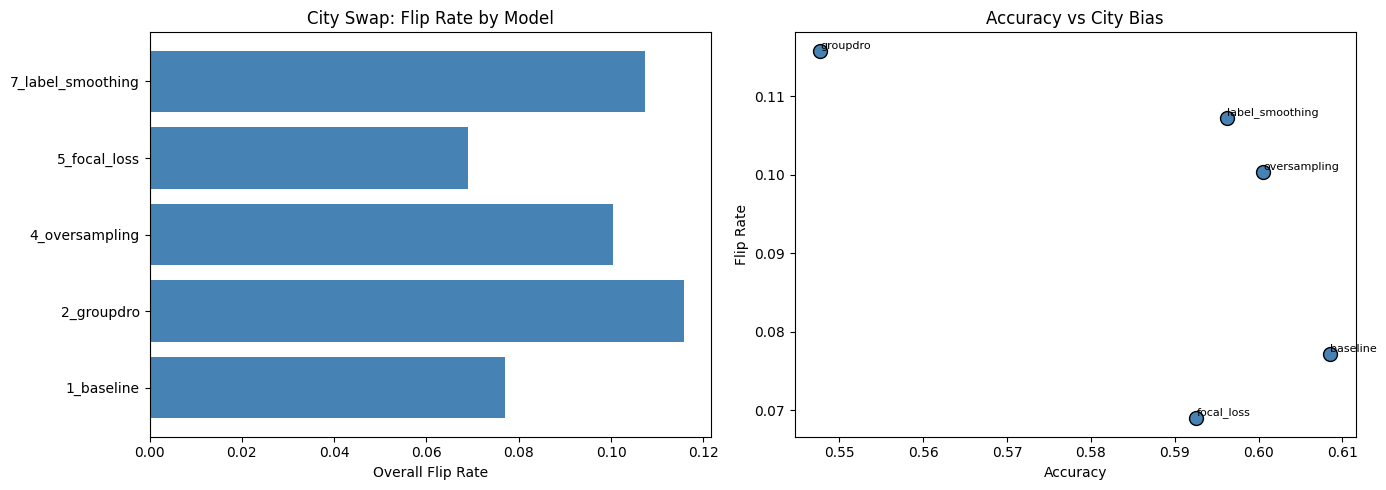

In [45]:
try:
    import matplotlib.pyplot as plt

    if non_scrub:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))

        names = list(non_scrub.keys())
        flips = [non_scrub[n]["overall_flip_rate"] for n in names]
        axes[0].barh(names, flips, color="steelblue")
        axes[0].set_xlabel("Overall Flip Rate")
        axes[0].set_title("City Swap: Flip Rate by Model")
        axes[0].axvline(x=0, color="red", linestyle="--", alpha=0.5)

        accs = [non_scrub[n]["accuracy"] for n in names]
        axes[1].scatter(accs, flips, s=100, c="steelblue", edgecolors="black")
        for i, name in enumerate(names):
            axes[1].annotate(name.split("_", 1)[1], (accs[i], flips[i]),
                           fontsize=8, ha="left", va="bottom")
        axes[1].set_xlabel("Accuracy")
        axes[1].set_ylabel("Flip Rate")
        axes[1].set_title("Accuracy vs City Bias")

        plt.tight_layout()
        plt.savefig(OUTPUT_DIR / "city_swap_chart.png", dpi=150, bbox_inches="tight")
        plt.show()
except ImportError:
    print("matplotlib not installed, skipping charts")